# ml_cluster_codes

本 notebook 为 `ml_cluster_lec.ipynb` 生成模拟数据和配图。

**数据设计**：

| 数据集 | 样本量 | 说明 | 用途 |
|---|:---:|---|---|
| 数据集 C（客户）| 500 | 年均消费额 × 消费频率，3 个规则球形簇 | K-means 主例 |
| 数据集 B（债券）| 200 | 4 维债券特征，4 个形状略不规则的簇 | 层次聚类主例 |
| 数据集 N（非球形）| 300 | 月牙形 + 同心圆结构 | K-means 局限演示 |

**图片命名规则**：`ml_cluster_fig{NN}_{描述}.png / .svg`

| 图号 | 文件名 | 布局 | figsize |
|---|---|:---:|:---:|
| 01 | `ml_cluster_fig01_data_C` | 单图 | (8, 5) |
| 02 | `ml_cluster_fig02_kmeans_iter` | 2×2 四图 | (8, 7) |
| 03 | `ml_cluster_fig03_kmeans_result` | 单图 | (8, 5) |
| 04 | `ml_cluster_fig04_local_optima` | 三图 | (8, 2.8) |
| 05 | `ml_cluster_fig05_elbow` | 单图 | (8, 5) |
| 06 | `ml_cluster_fig06_silhouette` | 双图 | (8, 4) |
| 07 | `ml_cluster_fig07_dendrogram` | 单图 | (8, 5) |
| 08 | `ml_cluster_fig08_linkage` | 三图 | (8, 2.8) |
| 09 | `ml_cluster_fig09_cut` | 双图 | (8, 4) |
| 10 | `ml_cluster_fig10_compare` | 双图 | (8, 4) |
| 11 | `ml_cluster_fig11_nonconvex` | 三图 | (8, 2.8) |
| 12 | `ml_cluster_fig12_pca_cluster` | 双图 | (8, 4) |


In [5]:
# !pip install --upgrade matplotlib

In [6]:
# ------------------------------------------------------------
# 0. 全局设置
# ------------------------------------------------------------

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles

warnings.filterwarnings('ignore')
os.makedirs('./figs', exist_ok=True)
os.makedirs('./data', exist_ok=True)

# ── 中文字体 ──
available_fonts = {f.name for f in fm.fontManager.ttflist}
font_candidates = [
    'SimHei', 'Microsoft YaHei', 'Noto Sans CJK SC',
    'Noto Sans CJK JP', 'WenQuanYi Micro Hei',
    'Arial Unicode MS', 'DejaVu Sans',
]
FONT_FAMILY = next(
    (f for f in font_candidates if f in available_fonts), 'DejaVu Sans'
)
plt.rcParams['font.sans-serif'] = [FONT_FAMILY]
plt.rcParams['axes.unicode_minus'] = False

# ── 全局基础配置 ──
plt.rcParams.update({
    'figure.dpi':      150,
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'axes.grid':        True,
    'grid.alpha':       0.22,
})

# ── 场景切换函数 ──
def fig_single():
    plt.rcParams.update({
        'figure.figsize':  (8, 5), 'font.size':       11,
        'legend.fontsize': 10,     'axes.labelsize':  11,
        'xtick.labelsize': 10,     'ytick.labelsize': 10,
    })

def fig_double():
    plt.rcParams.update({
        'figure.figsize':  (8, 4), 'font.size':       10,
        'legend.fontsize': 9,      'axes.labelsize':  10,
        'xtick.labelsize': 9,      'ytick.labelsize': 9,
    })

def fig_triple():
    plt.rcParams.update({
        'figure.figsize':  (8, 2.8), 'font.size':       9,
        'legend.fontsize': 8,        'axes.labelsize':  9,
        'xtick.labelsize': 8,        'ytick.labelsize': 8,
    })

def save_fig(fig, basename):
    # bbox_inches 和 facecolor 直接在 savefig 里传，不依赖 rcParams
    fig.savefig(f'./figs/{basename}.png',
                dpi=150, bbox_inches='tight', facecolor='white')
    fig.savefig(f'./figs/{basename}.svg',
                bbox_inches='tight', facecolor='white')

# ── 配色：6 个簇最多，用色彩友好调色板 ──
PALETTE = ['#1A3A6B', '#C8900A', '#2E8B57', '#CC2222', '#7B3F9E', '#666666']

RNG = np.random.default_rng(2026)
print(f'字体: {FONT_FAMILY}')

字体: SimHei


In [25]:
# ------------------------------------------------------------
# 1. 生成数据集 C：客户消费行为，3 个球形簇
# ------------------------------------------------------------
# 经济背景：
#   簇 0（低消费低频）：价格敏感型客户
#   簇 1（高消费低频）：大额偶发型客户
#   簇 2（中消费高频）：日常高频型客户
# ------------------------------------------------------------

n_C = 500

centers_C = np.array([
    [1500, 3.5],   # 簇 0
    [8000, 2.0],   # 簇 1
    [4500, 9.0],   # 簇 2
])
stds_C = np.array([
    [500,  0.6],
    [900,  0.5],
    [700,  0.8],
])
sizes_C = [160, 170, 170]

X_C_parts, y_C_parts = [], []
for k, (center, std, size) in enumerate(zip(centers_C, stds_C, sizes_C)):
    pts = RNG.normal(center, std, size=(size, 2))
    X_C_parts.append(pts)
    y_C_parts.append(np.full(size, k))

X_C = np.vstack(X_C_parts)
y_C = np.concatenate(y_C_parts)

# 打乱顺序（模拟真实未标注数据）
perm = RNG.permutation(n_C)
X_C, y_C = X_C[perm], y_C[perm]

df_C = pd.DataFrame(X_C, columns=['annual_spend', 'freq_per_month'])
df_C['true_cluster'] = y_C
df_C.to_csv('./data/cluster_customers.csv', index=False, encoding='utf-8-sig')

print(f'数据集 C: {X_C.shape}, 簇分布: {dict(zip(*np.unique(y_C, return_counts=True)))}')
print(df_C[['annual_spend','freq_per_month']].describe().round(1))

数据集 C: (500, 2), 簇分布: {np.int64(0): np.int64(160), np.int64(1): np.int64(170), np.int64(2): np.int64(170)}
       annual_spend  freq_per_month
count         500.0           500.0
mean         4744.1             4.9
std          2765.4             3.1
min           305.4             0.5
25%          1944.6             2.3
50%          4476.9             3.5
75%          7478.8             8.6
max          9861.2            11.4


In [8]:
# ------------------------------------------------------------
# 2. 生成数据集 B：债券特征，4 个簇（层次聚类主例）
# ------------------------------------------------------------
# 特征：duration（久期）、credit_spread（信用利差）、
#       liquidity（流动性溢价）、rating_score（评级得分）
# 4 类：国债、投资级企业债、高收益债、新兴市场债
# ------------------------------------------------------------

n_B = 200

bond_specs = [
    # center                       cov_diag          size  name
    ([5.0,  0.3,  0.1, 9.0],  [0.6, 0.04, 0.02, 0.3],  50, '国债'),
    ([6.5,  1.2,  0.4, 7.0],  [0.8, 0.10, 0.05, 0.5],  50, '投资级企业债'),
    ([4.0,  3.8,  1.2, 4.5],  [0.9, 0.25, 0.15, 0.6],  50, '高收益债'),
    ([7.5,  2.2,  0.8, 5.5],  [1.1, 0.18, 0.10, 0.7],  50, '新兴市场债'),
]

X_B_parts, y_B_parts, names_B = [], [], []
for k, (center, cov_d, size, name) in enumerate(bond_specs):
    pts = RNG.normal(center, np.sqrt(cov_d), size=(size, 4))
    X_B_parts.append(pts)
    y_B_parts.append(np.full(size, k))
    names_B.append(name)

X_B = np.vstack(X_B_parts)
y_B = np.concatenate(y_B_parts)

perm_B = RNG.permutation(n_B)
X_B, y_B = X_B[perm_B], y_B[perm_B]

bond_cols = ['duration', 'credit_spread', 'liquidity', 'rating_score']
df_B = pd.DataFrame(X_B, columns=bond_cols)
df_B['true_cluster'] = y_B
df_B.to_csv('./data/cluster_bonds.csv', index=False, encoding='utf-8-sig')

print(f'数据集 B: {X_B.shape}')
bond_names = ['国债', '投资级企业债', '高收益债', '新兴市场债']

数据集 B: (200, 4)


In [9]:
# ------------------------------------------------------------
# 3. 生成数据集 N：非球形结构（月牙 + 同心圆）
# ------------------------------------------------------------

# 月牙形
X_moon, y_moon = make_moons(n_samples=200, noise=0.08, random_state=42)

# 同心圆
X_circ, y_circ = make_circles(n_samples=200, noise=0.06,
                               factor=0.45, random_state=42)

# 细长椭圆形（手动生成）
theta = RNG.uniform(0, 2*np.pi, 150)
r1 = 0.15 + RNG.normal(0, 0.03, 150)
x1 = 3*r1*np.cos(theta) + RNG.normal(0, 0.05, 150)
x2 = 0.4*r1*np.sin(theta) + RNG.normal(0, 0.05, 150)
# 两个交叉细长簇
pts_a = np.c_[x1,  x2]
pts_b = np.c_[-x2, x1]   # 旋转 90 度
X_elong = np.vstack([pts_a, pts_b])
y_elong = np.r_[np.zeros(150), np.ones(150)].astype(int)

print('数据集 N（月牙）:', X_moon.shape)
print('数据集 N（同心圆）:', X_circ.shape)
print('数据集 N（细长椭圆）:', X_elong.shape)

数据集 N（月牙）: (200, 2)
数据集 N（同心圆）: (200, 2)
数据集 N（细长椭圆）: (300, 2)


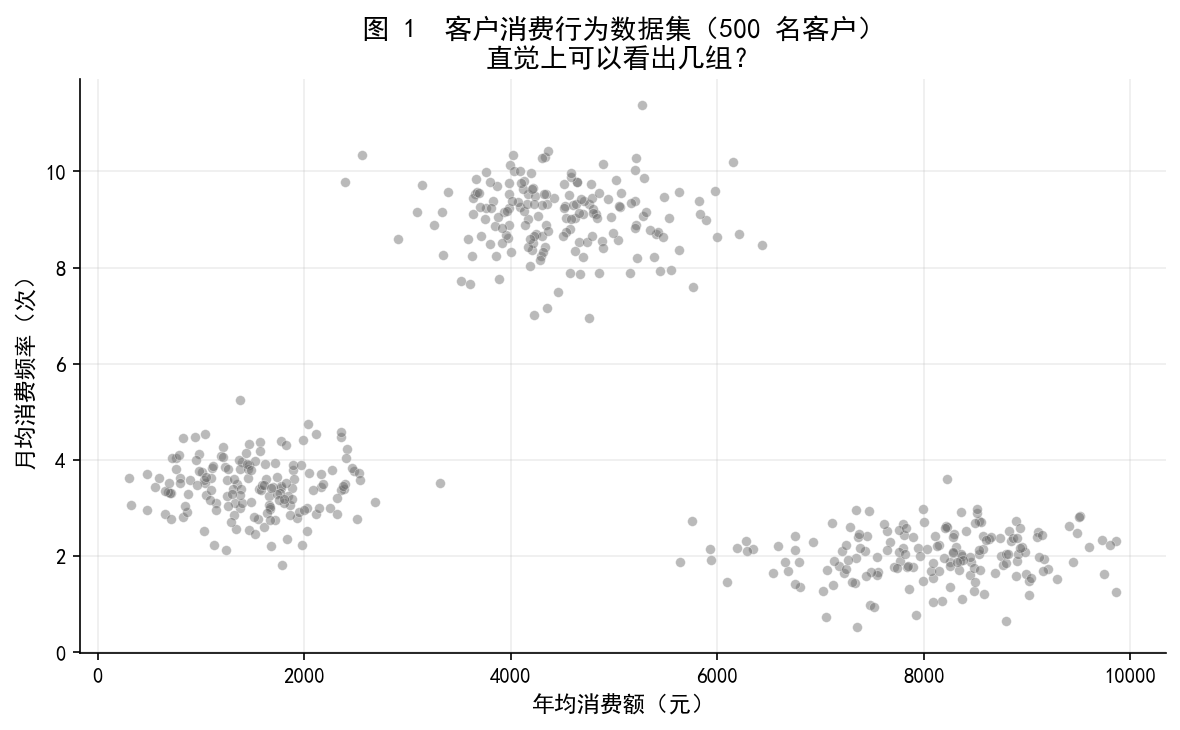

In [26]:
# ------------------------------------------------------------
# 图 01：数据集 C 原始散点图（未聚类，颜色相同）
# ml_cluster_fig01_data_C
# ------------------------------------------------------------

fig_single()
fig, ax = plt.subplots()

ax.scatter(X_C[:, 0], X_C[:, 1],
           color='#666666', alpha=0.45, s=22,
           edgecolors='white', linewidths=0.3)

ax.set_xlabel('年均消费额（元）')
ax.set_ylabel('月均消费频率（次）')
ax.set_title('图 1  客户消费行为数据集（500 名客户）\n'
             '直觉上可以看出几组？')
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig01_data_C')
plt.show()

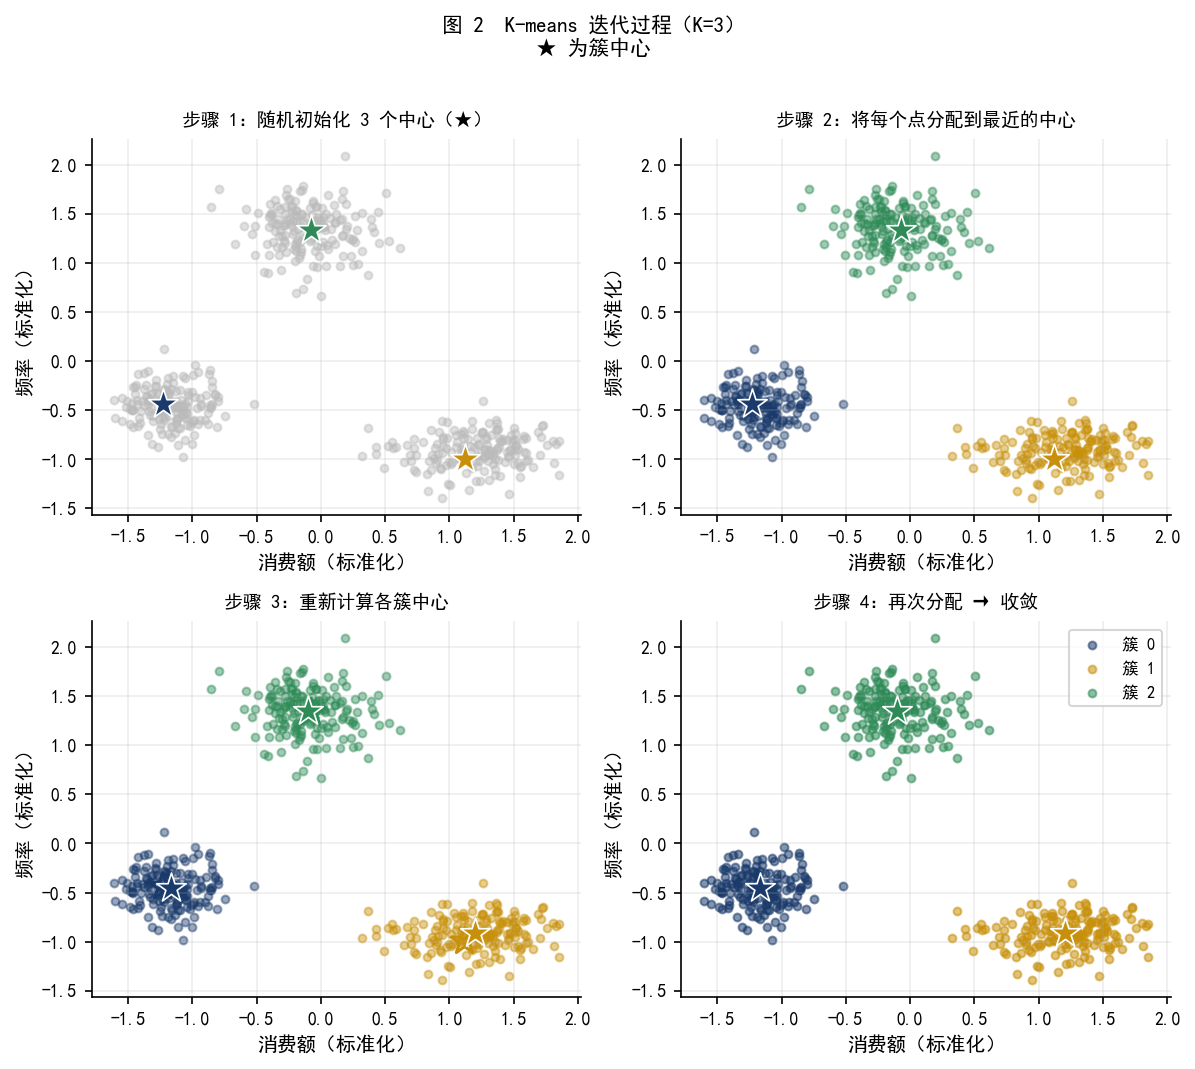

In [27]:
# ------------------------------------------------------------
# 图 02：K-means 迭代过程（4 步）
# ml_cluster_fig02_kmeans_iter
# ------------------------------------------------------------

# 对数据集 C 标准化
scaler_C = StandardScaler()
X_C_sc = scaler_C.fit_transform(X_C)

# 手动模拟 K-means 前 4 步
K = 3
# 固定初始中心（便于展示）
init_centers = X_C_sc[[12, 180, 350]].copy()

def assign_clusters(X, centers):
    dists = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
    return np.argmin(dists, axis=1)

def update_centers(X, labels, K):
    return np.array([X[labels == k].mean(axis=0) for k in range(K)])

plt.rcParams.update({
    'figure.figsize': (8, 7), 'font.size': 9.5,
    'legend.fontsize': 8.5,  'axes.labelsize': 9.5,
    'xtick.labelsize': 8.5,  'ytick.labelsize': 8.5,
})

fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

centers = init_centers.copy()
step_titles = [
    '步骤 1：随机初始化 3 个中心（★）',
    '步骤 2：将每个点分配到最近的中心',
    '步骤 3：重新计算各簇中心',
    '步骤 4：再次分配 → 收敛',
]

for step, (ax, title) in enumerate(zip(axes, step_titles)):
    if step == 0:
        # 尚未分配，全灰
        ax.scatter(X_C_sc[:, 0], X_C_sc[:, 1],
                   color='#bbbbbb', alpha=0.45, s=14)
        for k, c in enumerate(centers):
            ax.scatter(*c, marker='*', s=220,
                       color=PALETTE[k], zorder=5,
                       edgecolors='white', linewidths=0.8)
    elif step == 1:
        labels = assign_clusters(X_C_sc, centers)
        for k in range(K):
            ax.scatter(X_C_sc[labels==k, 0], X_C_sc[labels==k, 1],
                       color=PALETTE[k], alpha=0.45, s=14)
        for k, c in enumerate(centers):
            ax.scatter(*c, marker='*', s=220,
                       color=PALETTE[k], zorder=5,
                       edgecolors='white', linewidths=0.8)
    elif step == 2:
        labels = assign_clusters(X_C_sc, centers)
        new_centers = update_centers(X_C_sc, labels, K)
        for k in range(K):
            ax.scatter(X_C_sc[labels==k, 0], X_C_sc[labels==k, 1],
                       color=PALETTE[k], alpha=0.45, s=14)
        # 旧中心（空心）→ 新中心（实心）+ 箭头
        for k in range(K):
            ax.scatter(*centers[k], marker='*', s=180,
                       facecolors='none', edgecolors=PALETTE[k],
                       linewidths=1.5, zorder=4)
            ax.annotate('', xy=new_centers[k], xytext=centers[k],
                        arrowprops=dict(arrowstyle='->',
                                        color=PALETTE[k], lw=1.5))
            ax.scatter(*new_centers[k], marker='*', s=220,
                       color=PALETTE[k], zorder=5,
                       edgecolors='white', linewidths=0.8)
        centers = new_centers
    else:
        # 第二轮分配（收敛）
        labels = assign_clusters(X_C_sc, centers)
        for k in range(K):
            ax.scatter(X_C_sc[labels==k, 0], X_C_sc[labels==k, 1],
                       color=PALETTE[k], alpha=0.55, s=14,
                       label=f'簇 {k}')
        for k, c in enumerate(centers):
            ax.scatter(*c, marker='*', s=220,
                       color=PALETTE[k], zorder=5,
                       edgecolors='white', linewidths=0.8)
        ax.legend(fontsize=8, loc='upper right')

    ax.set_title(title, fontsize=9)
    ax.set_xlabel('消费额（标准化）')
    ax.set_ylabel('频率（标准化）')

fig.suptitle('图 2  K-means 迭代过程（K=3）\n★ 为簇中心',
             fontsize=10, y=1.01)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig02_kmeans_iter')
plt.show()

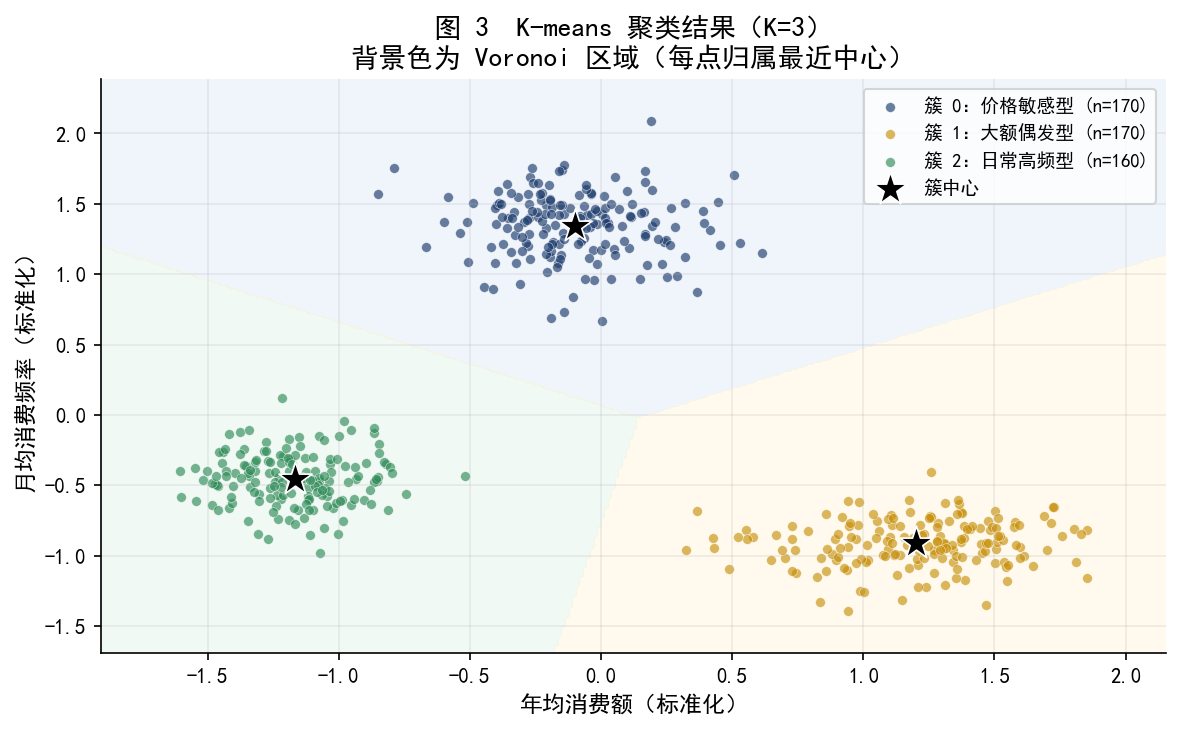

WCSS（inertia）= 53.44


In [28]:
# ------------------------------------------------------------
# 图 03：K-means 最终聚类结果
# ml_cluster_fig03_kmeans_result
# ------------------------------------------------------------

fig_single()

km_final = KMeans(n_clusters=3, n_init=20, random_state=42)
km_final.fit(X_C_sc)
labels_C = km_final.labels_
centers_final = km_final.cluster_centers_

# 绘制 Voronoi 背景色
x_min, x_max = X_C_sc[:,0].min()-0.3, X_C_sc[:,0].max()+0.3
y_min, y_max = X_C_sc[:,1].min()-0.3, X_C_sc[:,1].max()+0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))
Z = km_final.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

bg_cmap = ListedColormap(['#D6E4F7', '#FFF3CC', '#D8F0E4'])

fig, ax = plt.subplots()
ax.contourf(xx, yy, Z, levels=[-0.5,0.5,1.5,2.5],
            cmap=bg_cmap, alpha=0.35, zorder=0)

cluster_labels_cn = ['价格敏感型', '大额偶发型', '日常高频型']
for k in range(3):
    mask = labels_C == k
    ax.scatter(X_C_sc[mask,0], X_C_sc[mask,1],
               color=PALETTE[k], alpha=0.65, s=22,
               edgecolors='white', linewidths=0.3,
               label=f'簇 {k}：{cluster_labels_cn[k]} (n={mask.sum()})')
ax.scatter(centers_final[:,0], centers_final[:,1],
           marker='*', s=280, color='black', zorder=5,
           edgecolors='white', linewidths=0.8, label='簇中心')

ax.set_xlabel('年均消费额（标准化）')
ax.set_ylabel('月均消费频率（标准化）')
ax.set_title('图 3  K-means 聚类结果（K=3）\n'
             '背景色为 Voronoi 区域（每点归属最近中心）')
ax.legend(fontsize=9)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig03_kmeans_result')
plt.show()

print(f'WCSS（inertia）= {km_final.inertia_:.2f}')

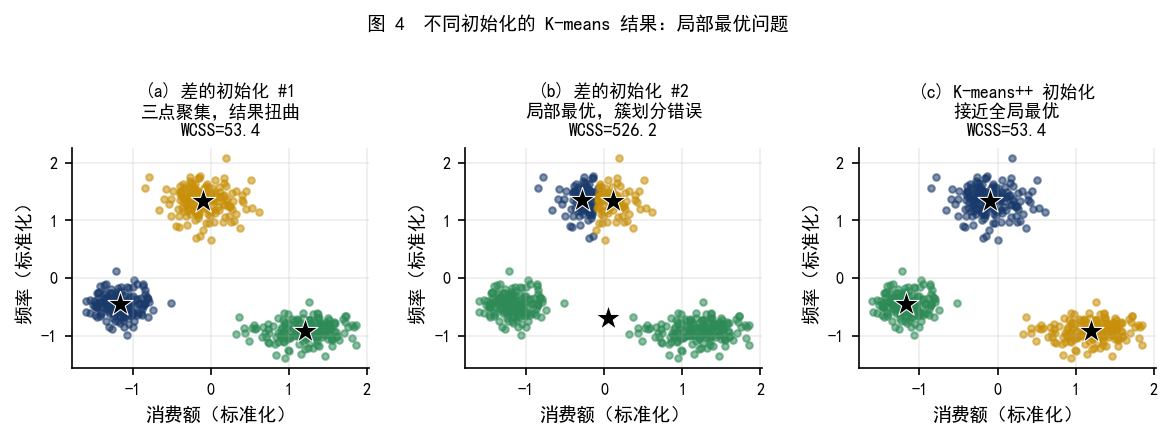

In [29]:
# ------------------------------------------------------------
# 图 04：不同随机初始化的结果对比（局部最优）
# ml_cluster_fig04_local_optima
# ------------------------------------------------------------

fig_triple()

# 三种初始化：一个好（接近全局最优）、两个差（局部最优）
bad_inits = [
    np.array([[-0.5, -0.5], [-0.4, -0.4], [-0.3, -0.3]]),  # 三个中心挤在一起
    np.array([[-1.5, 1.5], [1.5, 1.5], [0.0, -1.5]]),       # 中心在边角
]

fig, axes = plt.subplots(1, 3)

for ax, (init_type, title) in zip(axes, [
    ('bad1', '(a) 差的初始化 #1\n三点聚集，结果扭曲'),
    ('bad2', '(b) 差的初始化 #2\n局部最优，簇划分错误'),
    ('good', '(c) K-means++ 初始化\n接近全局最优'),
]):
    if init_type == 'bad1':
        km = KMeans(n_clusters=3, init=bad_inits[0], n_init=1, random_state=0)
    elif init_type == 'bad2':
        km = KMeans(n_clusters=3, init=bad_inits[1], n_init=1, random_state=0)
    else:
        km = KMeans(n_clusters=3, init='k-means++', n_init=1, random_state=42)

    km.fit(X_C_sc)
    lbls = km.labels_
    inertia = km.inertia_

    for k in range(3):
        ax.scatter(X_C_sc[lbls==k,0], X_C_sc[lbls==k,1],
                   color=PALETTE[k], alpha=0.55, s=10)
    ax.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
               marker='*', s=160, color='black', zorder=5,
               edgecolors='white', linewidths=0.5)
    ax.set_title(f'{title}\nWCSS={inertia:.1f}', fontsize=8.5)
    ax.set_xlabel('消费额（标准化）')
    ax.set_ylabel('频率（标准化）')

fig.suptitle('图 4  不同初始化的 K-means 结果：局部最优问题',
             fontsize=9, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig04_local_optima')
plt.show()

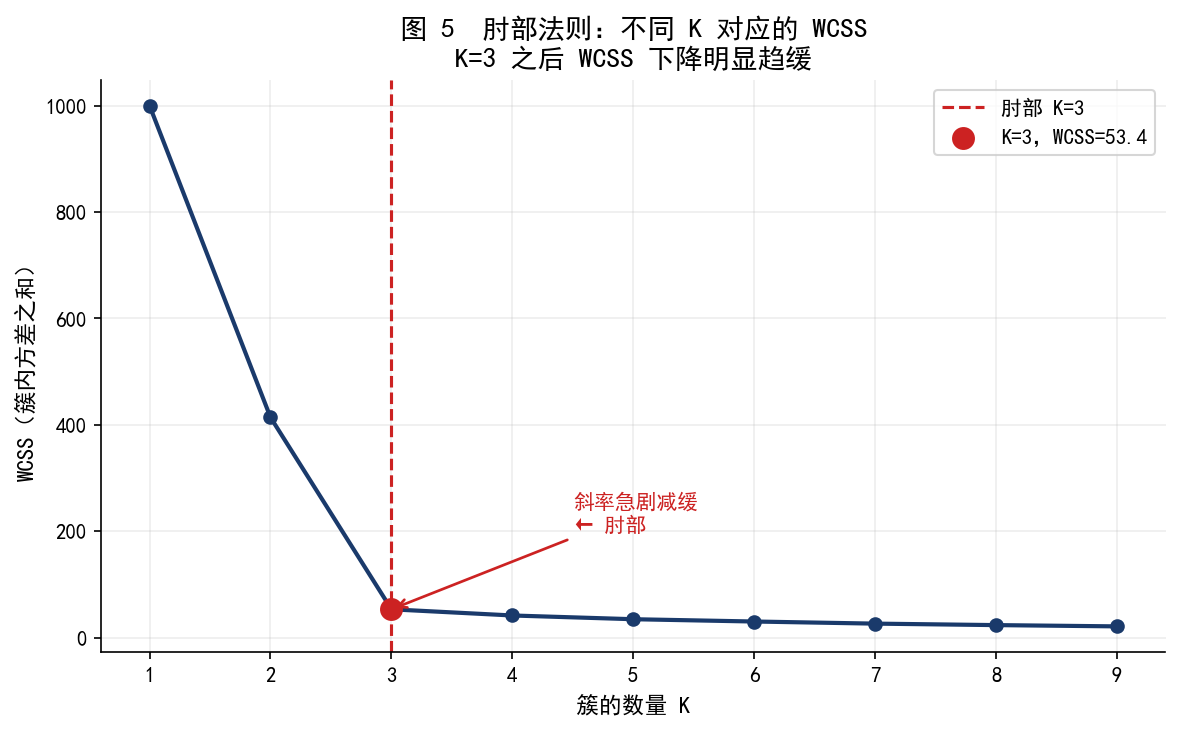

In [30]:
# ------------------------------------------------------------
# 图 05：肘部法则（Elbow Method）
# ml_cluster_fig05_elbow
# ------------------------------------------------------------

fig_single()

inertias = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(X_C_sc)
    inertias.append(km.inertia_)

fig, ax = plt.subplots()
ax.plot(list(K_range), inertias, 'o-',
        color=PALETTE[0], lw=2.0, ms=6)

# 标注肘部 K=3
ax.axvline(3, color=PALETTE[3], lw=1.5, linestyle='--',
           label='肘部 K=3')
ax.scatter([3], [inertias[2]], s=100, color=PALETTE[3],
           zorder=5, label=f'K=3，WCSS={inertias[2]:.1f}')

# 标注斜率变化
ax.annotate('斜率急剧减缓\n← 肘部',
            xy=(3, inertias[2]),
            xytext=(4.5, inertias[2] + (inertias[0]-inertias[-1])*0.15),
            arrowprops=dict(arrowstyle='->', color=PALETTE[3], lw=1.3),
            fontsize=10, color=PALETTE[3])

ax.set_xlabel('簇的数量 K')
ax.set_ylabel('WCSS（簇内方差之和）')
ax.set_title('图 5  肘部法则：不同 K 对应的 WCSS\n'
             'K=3 之后 WCSS 下降明显趋缓')
ax.set_xticks(list(K_range))
ax.legend(fontsize=10)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig05_elbow')
plt.show()

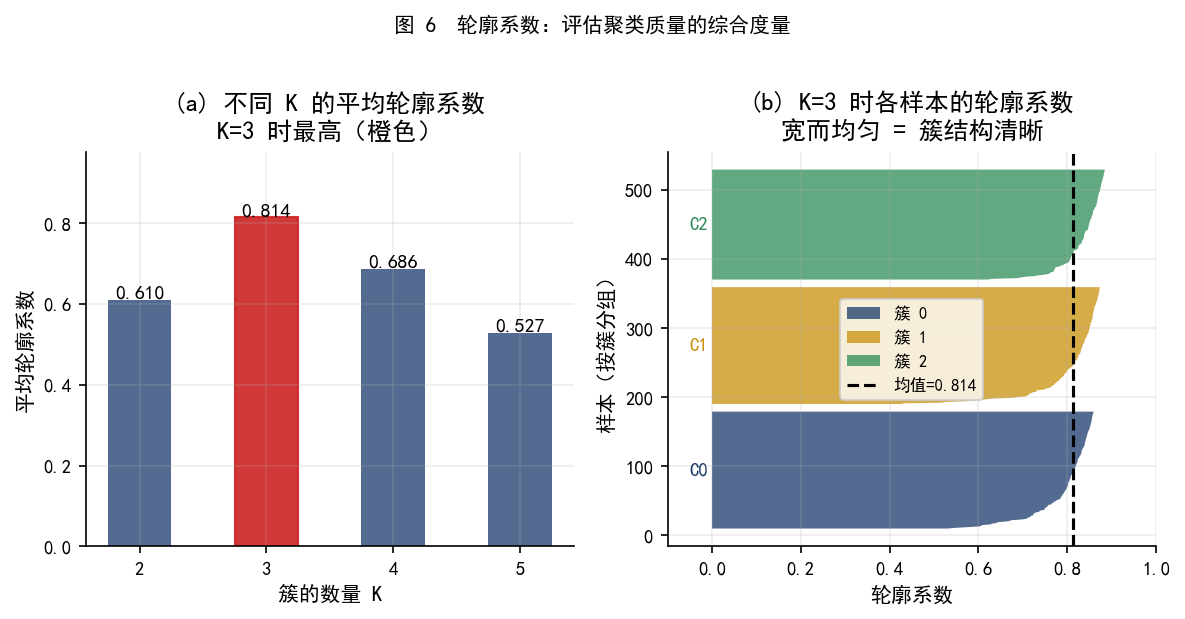

In [31]:
# ------------------------------------------------------------
# 图 06：轮廓系数图
# ml_cluster_fig06_silhouette
# ------------------------------------------------------------

fig_double()

# 计算 K=2,3,4,5 的平均轮廓系数
sil_scores = {}
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    lbls = km.fit_predict(X_C_sc)
    sil_scores[k] = silhouette_score(X_C_sc, lbls)

fig, axes = plt.subplots(1, 2)

# 左图：不同 K 的平均轮廓系数
ax = axes[0]
ks = list(sil_scores.keys())
ss = list(sil_scores.values())
bars = ax.bar(ks, ss, color=[PALETTE[0]]*4, alpha=0.75, width=0.5)
best_k_sil = ks[np.argmax(ss)]
bars[ks.index(best_k_sil)].set_color(PALETTE[3])
bars[ks.index(best_k_sil)].set_alpha(0.9)
for bar, val in zip(bars, ss):
    ax.text(bar.get_x()+bar.get_width()/2,
            val+0.005, f'{val:.3f}',
            ha='center', fontsize=9.5)
ax.set_xlabel('簇的数量 K')
ax.set_ylabel('平均轮廓系数')
ax.set_title(f'(a) 不同 K 的平均轮廓系数\nK={best_k_sil} 时最高（橙色）')
ax.set_xticks(ks)
ax.set_ylim(0, max(ss)*1.2)

# 右图：K=3 的逐样本轮廓系数图
ax2 = axes[1]
km3 = KMeans(n_clusters=3, n_init=20, random_state=42)
lbls3 = km3.fit_predict(X_C_sc)
sil_vals = silhouette_samples(X_C_sc, lbls3)

y_lower = 10
for k in range(3):
    sil_k = np.sort(sil_vals[lbls3 == k])
    size_k = len(sil_k)
    y_upper = y_lower + size_k
    ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_k,
                       facecolor=PALETTE[k], alpha=0.75,
                       label=f'簇 {k}')
    ax2.text(-0.05, y_lower + size_k/2, f'C{k}', fontsize=9,
             color=PALETTE[k], va='center')
    y_lower = y_upper + 10

ax2.axvline(sil_scores[3], color='black', lw=1.5, linestyle='--',
            label=f'均值={sil_scores[3]:.3f}')
ax2.set_xlabel('轮廓系数')
ax2.set_ylabel('样本（按簇分组）')
ax2.set_title('(b) K=3 时各样本的轮廓系数\n宽而均匀 = 簇结构清晰')
ax2.legend(fontsize=8)
ax2.set_xlim(-0.1, 1.0)

fig.suptitle('图 6  轮廓系数：评估聚类质量的综合度量',
             fontsize=10, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig06_silhouette')
plt.show()

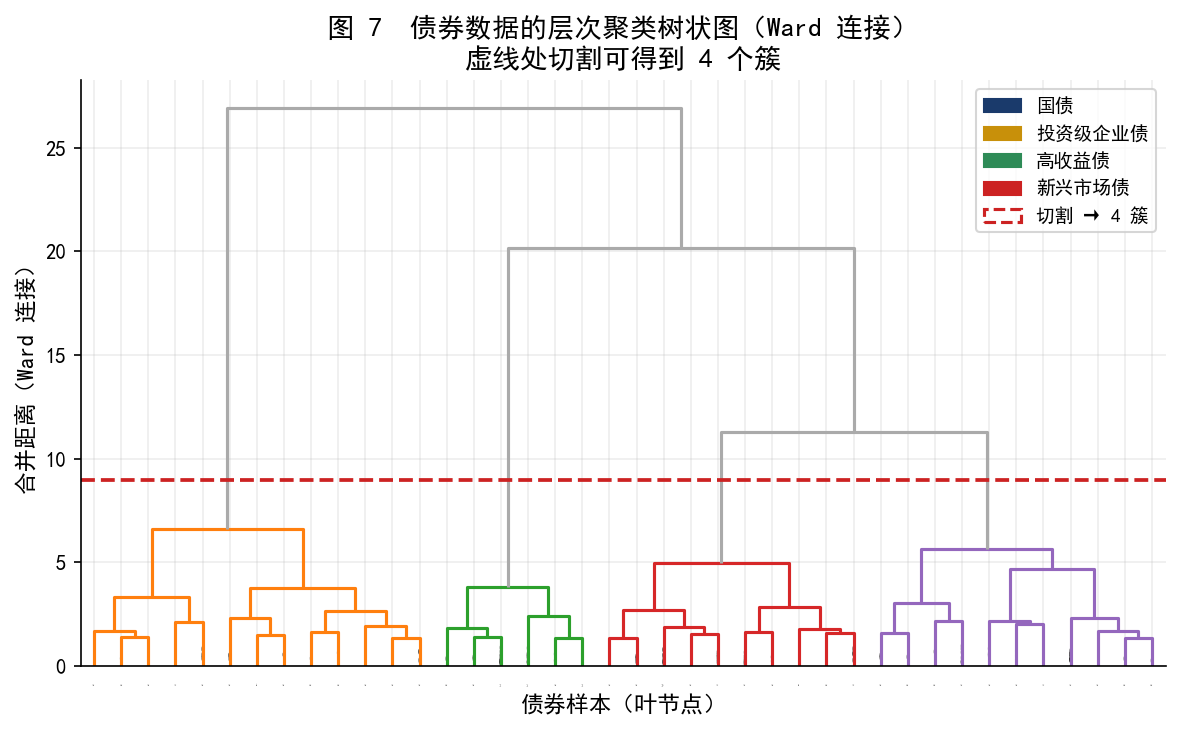

In [32]:
# ------------------------------------------------------------
# 图 07：债券数据的层次聚类树状图（Ward 连接）
# ml_cluster_fig07_dendrogram
# ------------------------------------------------------------

fig_single()

X_B_sc = StandardScaler().fit_transform(X_B)

Z_ward = linkage(X_B_sc, method='ward')

fig, ax = plt.subplots(figsize=(8, 5))

# 按真实类别着色叶节点
color_map = {}
for i, label in enumerate(y_B):
    color_map[i] = PALETTE[int(label)]

dend = dendrogram(
    Z_ward,
    ax=ax,
    truncate_mode='lastp',
    p=40,
    leaf_rotation=90,
    leaf_font_size=0,
    color_threshold=Z_ward[-3, 2],
    above_threshold_color='#aaaaaa',
    show_contracted=True,
)

# 水平切割线（4 个簇）
cut_height = (Z_ward[-3, 2] + Z_ward[-4, 2]) / 2
ax.axhline(cut_height, color=PALETTE[3], lw=1.8,
           linestyle='--', label=f'切割高度 → 4 个簇')

# 图例（债券类别）
patches = [mpatches.Patch(color=PALETTE[k], label=bond_names[k])
           for k in range(4)]
ax.legend(handles=patches + [mpatches.Patch(
    color=PALETTE[3], label=f'切割 → 4 簇', linestyle='--',
    fill=False, linewidth=1.5)],
    fontsize=9, loc='upper right')

ax.set_xlabel('债券样本（叶节点）')
ax.set_ylabel('合并距离（Ward 连接）')
ax.set_title('图 7  债券数据的层次聚类树状图（Ward 连接）\n'
             '虚线处切割可得到 4 个簇')
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig07_dendrogram')
plt.show()

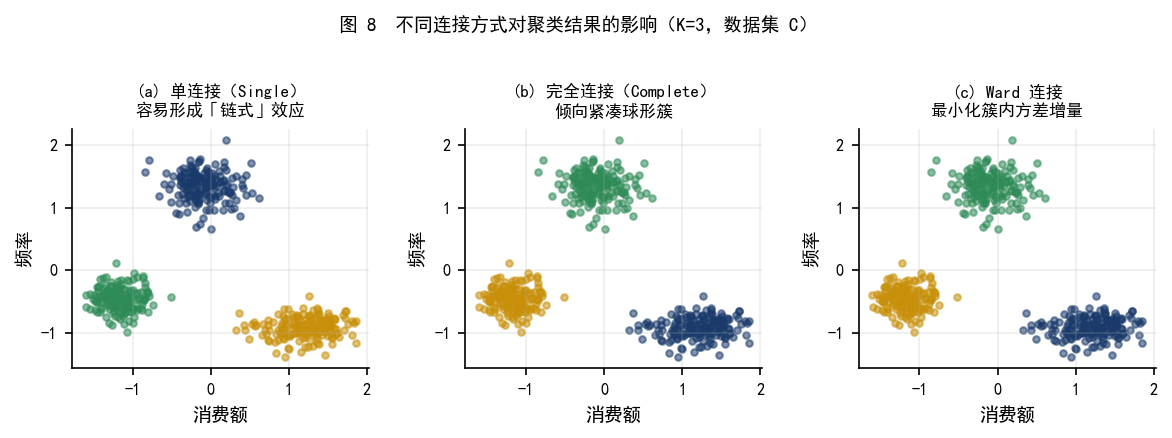

In [33]:
# ------------------------------------------------------------
# 图 08：不同连接方式（Linkage）对比
# ml_cluster_fig08_linkage
# 用数据集 C 的前两维展示 single / complete / ward 的差异
# ------------------------------------------------------------

fig_triple()

linkage_methods = ['single', 'complete', 'ward']
titles_lk = [
    '(a) 单连接（Single）\n容易形成「链式」效应',
    '(b) 完全连接（Complete）\n倾向紧凑球形簇',
    '(c) Ward 连接\n最小化簇内方差增量',
]

fig, axes = plt.subplots(1, 3)

for ax, method, title in zip(axes, linkage_methods, titles_lk):
    Z_lk = linkage(X_C_sc, method=method)
    lbls_lk = fcluster(Z_lk, t=3, criterion='maxclust') - 1

    for k in range(3):
        ax.scatter(X_C_sc[lbls_lk==k, 0],
                   X_C_sc[lbls_lk==k, 1],
                   color=PALETTE[k], alpha=0.55, s=10)
    ax.set_title(title, fontsize=8.2)
    ax.set_xlabel('消费额')
    ax.set_ylabel('频率')

fig.suptitle('图 8  不同连接方式对聚类结果的影响（K=3，数据集 C）',
             fontsize=9, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig08_linkage')
plt.show()

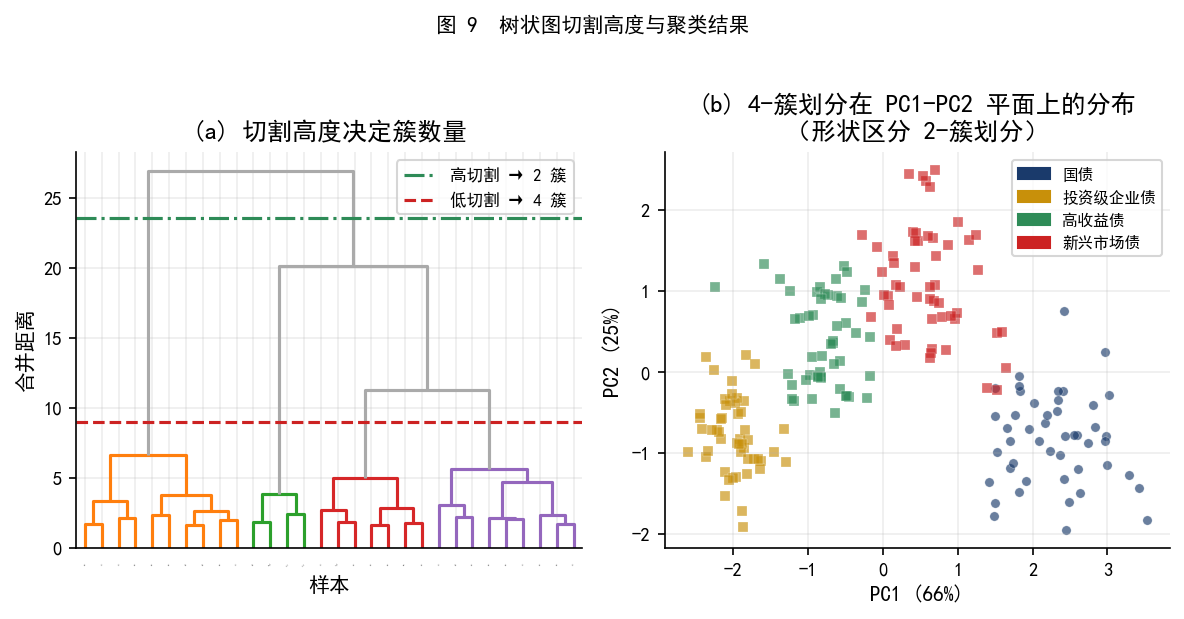

In [34]:
# ------------------------------------------------------------
# 图 09：从树状图切割得到不同簇数
# ml_cluster_fig09_cut
# ------------------------------------------------------------

fig_double()

fig, axes = plt.subplots(1, 2)

# 左图：树状图 + 两条不同高度切割线
ax = axes[0]
cut2 = (Z_ward[-1, 2] + Z_ward[-2, 2]) / 2  # → 2 个簇
cut4 = (Z_ward[-3, 2] + Z_ward[-4, 2]) / 2  # → 4 个簇

dendrogram(
    Z_ward, ax=ax,
    truncate_mode='lastp', p=30,
    leaf_font_size=0,
    color_threshold=cut4,
    above_threshold_color='#aaaaaa',
)
ax.axhline(cut2, color=PALETTE[2], lw=1.5, linestyle='-.',
           label=f'高切割 → 2 簇')
ax.axhline(cut4, color=PALETTE[3], lw=1.5, linestyle='--',
           label=f'低切割 → 4 簇')
ax.legend(fontsize=8)
ax.set_xlabel('样本')
ax.set_ylabel('合并距离')
ax.set_title('(a) 切割高度决定簇数量')

# 右图：2 种切割对应的散点（前两个主成分展示）
ax2 = axes[1]
pca_B = PCA(n_components=2)
X_B_2d = pca_B.fit_transform(X_B_sc)

lbls_2 = fcluster(Z_ward, t=2, criterion='maxclust') - 1
lbls_4 = fcluster(Z_ward, t=4, criterion='maxclust') - 1

# 用形状区分 2-簇划分，用颜色区分 4-簇划分
markers_2 = ['o', 's']
for k2 in range(2):
    for k4 in range(4):
        mask = (lbls_2 == k2) & (lbls_4 == k4)
        if mask.sum() > 0:
            ax2.scatter(X_B_2d[mask, 0], X_B_2d[mask, 1],
                        color=PALETTE[k4], marker=markers_2[k2],
                        alpha=0.65, s=20,
                        edgecolors='white', linewidths=0.2)

# 图例
p4 = [mpatches.Patch(color=PALETTE[k], label=bond_names[k]) for k in range(4)]
ax2.legend(handles=p4, fontsize=7.5, loc='best')
ax2.set_xlabel(f'PC1 ({pca_B.explained_variance_ratio_[0]:.0%})')
ax2.set_ylabel(f'PC2 ({pca_B.explained_variance_ratio_[1]:.0%})')
ax2.set_title('(b) 4-簇划分在 PC1-PC2 平面上的分布\n（形状区分 2-簇划分）')

fig.suptitle('图 9  树状图切割高度与聚类结果',
             fontsize=10, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig09_cut')
plt.show()

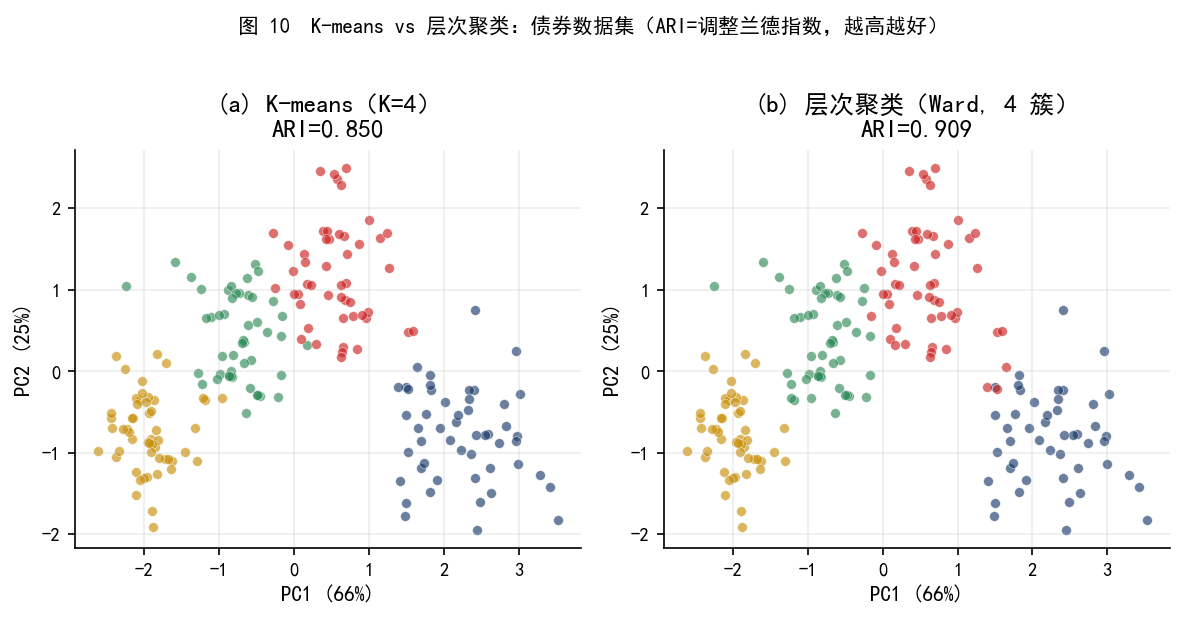

K-means  ARI = 0.8499
层次聚类 ARI = 0.9087


In [35]:
# ------------------------------------------------------------
# 图 10：K-means vs 层次聚类（债券数据集，PCA 展示）
# ml_cluster_fig10_compare
# ------------------------------------------------------------

fig_double()

# K-means（K=4）
km_B = KMeans(n_clusters=4, n_init=30, random_state=42)
lbls_km_B = km_B.fit_predict(X_B_sc)

# 层次聚类 Ward（4 簇）
lbls_hc_B = fcluster(Z_ward, t=4, criterion='maxclust') - 1

# 计算与真实标签的一致性（ARI）
from sklearn.metrics import adjusted_rand_score
ari_km = adjusted_rand_score(y_B, lbls_km_B)
ari_hc = adjusted_rand_score(y_B, lbls_hc_B)

fig, axes = plt.subplots(1, 2)

for ax, lbls, title in [
    (axes[0], lbls_km_B,
     f'(a) K-means（K=4）\nARI={ari_km:.3f}'),
    (axes[1], lbls_hc_B,
     f'(b) 层次聚类（Ward, 4 簇）\nARI={ari_hc:.3f}'),
]:
    for k in range(4):
        mask = lbls == k
        ax.scatter(X_B_2d[mask, 0], X_B_2d[mask, 1],
                   color=PALETTE[k], alpha=0.65, s=22,
                   edgecolors='white', linewidths=0.3)
    ax.set_xlabel(f'PC1 ({pca_B.explained_variance_ratio_[0]:.0%})')
    ax.set_ylabel(f'PC2 ({pca_B.explained_variance_ratio_[1]:.0%})')
    ax.set_title(title)

fig.suptitle('图 10  K-means vs 层次聚类：债券数据集（ARI=调整兰德指数，越高越好）',
             fontsize=10, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig10_compare')
plt.show()

print(f'K-means  ARI = {ari_km:.4f}')
print(f'层次聚类 ARI = {ari_hc:.4f}')

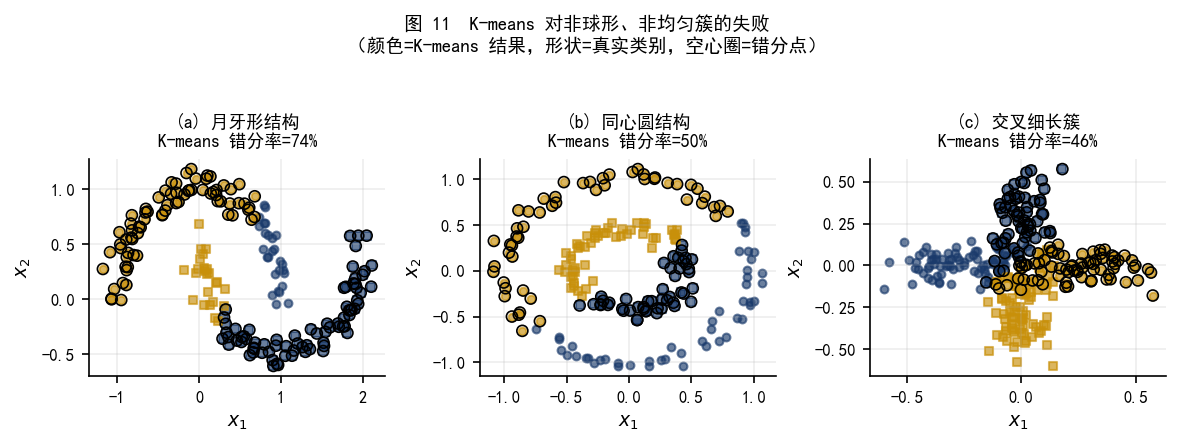

In [36]:
# ------------------------------------------------------------
# 图 11：K-means 对非球形簇的局限
# ml_cluster_fig11_nonconvex
# ------------------------------------------------------------

fig_triple()

datasets_nl = [
    (X_moon,  y_moon,  '(a) 月牙形结构'),
    (X_circ,  y_circ,  '(b) 同心圆结构'),
    (X_elong, y_elong, '(c) 交叉细长簇'),
]

fig, axes = plt.subplots(1, 3)

for ax, (X_nl, y_nl, title) in zip(axes, datasets_nl):
    k_nl = len(np.unique(y_nl))
    km_nl = KMeans(n_clusters=k_nl, n_init=20, random_state=42)
    lbls_nl = km_nl.fit_predict(X_nl)

    # 真实标签（形状）vs K-means 结果（颜色）
    markers_true = ['o', 's', '^']
    for kt in range(k_nl):
        for kp in range(k_nl):
            mask = (y_nl == kt) & (lbls_nl == kp)
            if mask.sum() > 0:
                ax.scatter(X_nl[mask, 0], X_nl[mask, 1],
                           color=PALETTE[kp],
                           marker=markers_true[kt],
                           alpha=0.65, s=14)

    # 标出错分点（形状与颜色不一致）
    wrong = y_nl != lbls_nl
    if wrong.sum() > 0:
        ax.scatter(X_nl[wrong, 0], X_nl[wrong, 1],
                   facecolors='none', edgecolors='black',
                   linewidths=0.8, s=28, zorder=5)

    err_rate = wrong.mean()
    ax.set_title(f'{title}\nK-means 错分率={err_rate:.0%}',
                 fontsize=8.5)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

fig.suptitle('图 11  K-means 对非球形、非均匀簇的失败\n'
             '（颜色=K-means 结果，形状=真实类别，空心圈=错分点）',
             fontsize=9, y=1.04)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig11_nonconvex')
plt.show()

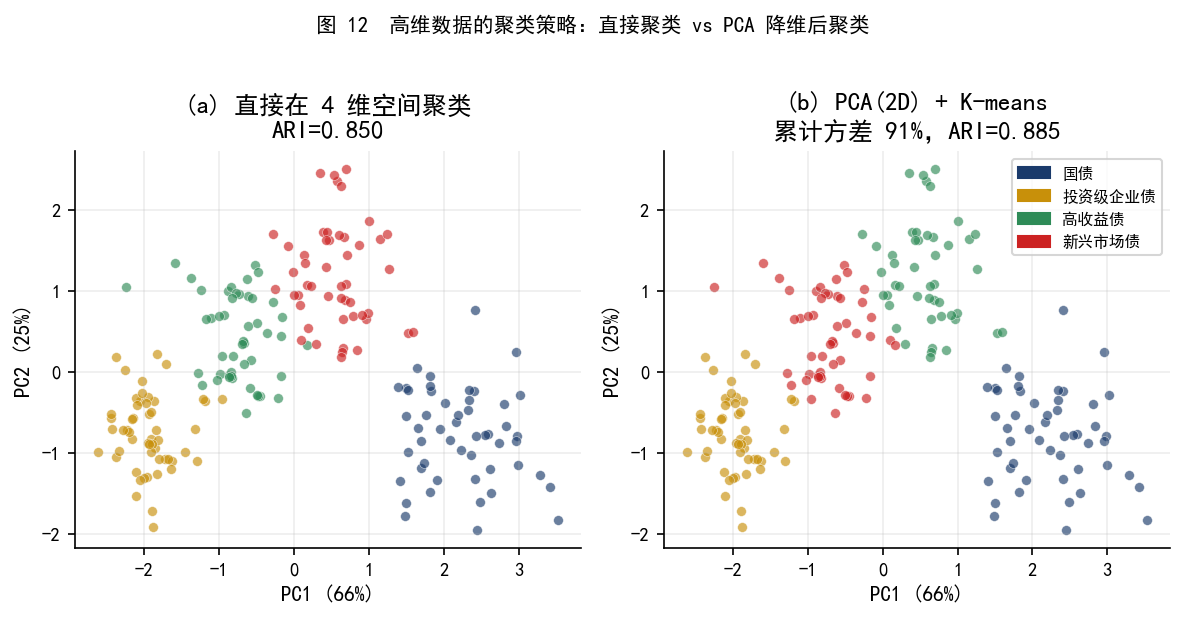

直接 4D K-means ARI = 0.8499
PCA(2D)+K-means ARI = 0.8851


In [37]:
# ------------------------------------------------------------
# 图 12：高维数据：先 PCA 降维再聚类
# ml_cluster_fig12_pca_cluster
# 用债券 4 维数据演示：直接聚类 vs PCA(2D) + 聚类
# ------------------------------------------------------------

fig_double()

# 方案 A：直接在 4 维标准化空间做 K-means
km_4d = KMeans(n_clusters=4, n_init=30, random_state=42)
lbls_4d = km_4d.fit_predict(X_B_sc)
ari_4d = adjusted_rand_score(y_B, lbls_4d)

# 方案 B：先 PCA 降到 2 维再做 K-means
X_B_pca2 = X_B_2d   # 已在前面计算
km_pca2 = KMeans(n_clusters=4, n_init=30, random_state=42)
lbls_pca2 = km_pca2.fit_predict(X_B_pca2)
ari_pca2 = adjusted_rand_score(y_B, lbls_pca2)

cum_var2 = pca_B.explained_variance_ratio_.sum()

fig, axes = plt.subplots(1, 2)

for ax, lbls, ari, title in [
    (axes[0], lbls_4d,
     ari_4d,
     f'(a) 直接在 4 维空间聚类\nARI={ari_4d:.3f}'),
    (axes[1], lbls_pca2,
     ari_pca2,
     f'(b) PCA(2D) + K-means\n累计方差 {cum_var2:.0%}，ARI={ari_pca2:.3f}'),
]:
    for k in range(4):
        mask = lbls == k
        ax.scatter(X_B_2d[mask, 0], X_B_2d[mask, 1],
                   color=PALETTE[k], alpha=0.65, s=22,
                   edgecolors='white', linewidths=0.3)
    ax.set_xlabel(f'PC1 ({pca_B.explained_variance_ratio_[0]:.0%})')
    ax.set_ylabel(f'PC2 ({pca_B.explained_variance_ratio_[1]:.0%})')
    ax.set_title(title)

patches = [mpatches.Patch(color=PALETTE[k], label=bond_names[k])
           for k in range(4)]
axes[1].legend(handles=patches, fontsize=7.5, loc='best')

fig.suptitle('图 12  高维数据的聚类策略：直接聚类 vs PCA 降维后聚类',
             fontsize=10, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig12_pca_cluster')
plt.show()

print(f'直接 4D K-means ARI = {ari_4d:.4f}')
print(f'PCA(2D)+K-means ARI = {ari_pca2:.4f}')